<a href="https://colab.research.google.com/github/peemoshi/ai-ml-internship/blob/main/week-2/2.1-neural-network-pytorch/pytorch_nn_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loads the UCI Adult Income dataset (~32,500 people) to predict whether someone earns more than $50K/year based on education, occupation, and other factors. Missing values in workclass, occupation, and native_country (marked ? in the raw data) are filled with "Unknown" rather than dropped, since a missing job status is likely meaningful (e.g., not in the labor force) rather than random.

In [1]:
import pandas as pd
import numpy as np

columns = ['age','workclass','fnlwgt','education','education_num','marital_status',
           'occupation','relationship','race','sex','capital_gain','capital_loss',
           'hours_per_week','native_country','income']

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
df = pd.read_csv(url, names=columns, na_values=' ?', skipinitialspace=True)

print(df.shape)
df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
print(df.isnull().sum())
print("\nRows with missing values:", df.isnull().any(axis=1).sum())
print("\nIncome distribution:\n", df['income'].value_counts())

# Check for the literal "?" character across all columns
for col in df.columns:
    count = (df[col].astype(str).str.strip() == '?').sum()
    if count > 0:
        print(f"{col}: {count} missing (marked '?')")

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Rows with missing values: 0

Income distribution:
 income
<=50K    24720
>50K      7841
Name: count, dtype: int64
workclass: 1836 missing (marked '?')
occupation: 1843 missing (marked '?')
native_country: 583 missing (marked '?')


In [5]:
for col in ['workclass', 'occupation', 'native_country']:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('?', 'Unknown')

# Confirm it worked
for col in ['workclass', 'occupation', 'native_country']:
    print(col, ":", (df[col] == 'Unknown').sum(), "filled")

workclass : 1836 filled
occupation : 1843 filled
native_country : 583 filled


Separates the data into features (X) and the income target (y), dropping fnlwgt (a statistical sampling weight, not a real trait) and education (a text duplicate of education_num). The data is split into train/test sets, then scaled and one-hot encoded fit only on the training set to avoid leaking test information into preprocessing.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

X = df.drop(columns=['income', 'fnlwgt', 'education'])
y = (df['income'] == '>50K').astype(int).values

numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

X_train_df, X_test_df, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X_train = preprocessor.fit_transform(X_train_df).astype(np.float32)
X_test = preprocessor.transform(X_test_df).astype(np.float32)

print("\nTraining shape:", X_train.shape)
print("Test shape:", X_test.shape)

Numeric: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

Training shape: (26048, 91)
Test shape: (6513, 91)


Converts the data into PyTorch tensors and wraps them in a Dataset and DataLoader, which serves the data in shuffled batches of 64 rather than all at once making this training efficient and stable.



In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.toarray() if hasattr(X_train, 'toarray') else X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test.toarray() if hasattr(X_test, 'toarray') else X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

class IncomeDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = IncomeDataset(X_train_tensor, y_train_tensor)
test_dataset = IncomeDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

sample_X, sample_y = next(iter(train_loader))
print("Batch X shape:", sample_X.shape)
print("Batch y shape:", sample_y.shape)

Batch X shape: torch.Size([64, 91])
Batch y shape: torch.Size([64, 1])


Defines a 3-layer feed-forward neural network (91 → 64 → 32 → 1) and trains it for 20 epochs using BCEWithLogitsLoss (standard for binary classification) and the Adam optimizer. Each epoch prints both training and test loss so overfitting can be tracked as it happens, not just guessed at afterward.

In [9]:
class IncomeClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)   # raw logit: no sigmoid here, see note below
        return x

model = IncomeClassifier(input_dim=X_train_tensor.shape[1])

# BCEWithLogitsLoss combines a sigmoid + binary cross-entropy loss in one step —
# more numerically stable than applying sigmoid yourself before a plain BCELoss
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
train_losses, test_losses = [], []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()          # 1. clear old gradients
        outputs = model(X_batch)       # 2. forward pass
        loss = criterion(outputs, y_batch)  # 3. compute loss
        loss.backward()                # 4. backpropagate
        optimizer.step()               # 5. update weights
        epoch_train_loss += loss.item()
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()                       # switch to evaluation mode (no dropout/batchnorm changes)
    epoch_test_loss = 0
    with torch.no_grad():              # no gradient tracking needed for evaluation
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            epoch_test_loss += loss.item()
    avg_test_loss = epoch_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch+1}/{num_epochs}  Train Loss: {avg_train_loss:.4f}  Test Loss: {avg_test_loss:.4f}")

Epoch 1/20  Train Loss: 0.3568  Test Loss: 0.3151
Epoch 2/20  Train Loss: 0.3127  Test Loss: 0.3046
Epoch 3/20  Train Loss: 0.3086  Test Loss: 0.3044
Epoch 4/20  Train Loss: 0.3062  Test Loss: 0.3033
Epoch 5/20  Train Loss: 0.3043  Test Loss: 0.3033
Epoch 6/20  Train Loss: 0.3038  Test Loss: 0.3018
Epoch 7/20  Train Loss: 0.3025  Test Loss: 0.3006
Epoch 8/20  Train Loss: 0.3006  Test Loss: 0.3001
Epoch 9/20  Train Loss: 0.2995  Test Loss: 0.3071
Epoch 10/20  Train Loss: 0.2987  Test Loss: 0.3024
Epoch 11/20  Train Loss: 0.2971  Test Loss: 0.3027
Epoch 12/20  Train Loss: 0.2963  Test Loss: 0.3010
Epoch 13/20  Train Loss: 0.2951  Test Loss: 0.3040
Epoch 14/20  Train Loss: 0.2940  Test Loss: 0.3060
Epoch 15/20  Train Loss: 0.2929  Test Loss: 0.3051
Epoch 16/20  Train Loss: 0.2917  Test Loss: 0.3088
Epoch 17/20  Train Loss: 0.2904  Test Loss: 0.3049
Epoch 18/20  Train Loss: 0.2894  Test Loss: 0.3084
Epoch 19/20  Train Loss: 0.2884  Test Loss: 0.3077
Epoch 20/20  Train Loss: 0.2875  Test Lo

Plots training vs. test loss per epoch to visualize the model's learning behavior. Training loss falls steadily throughout, but test loss plateaus around epoch 8 and drifts upward afterward this is a sign the model begins overfitting past that point rather than continuing to generalize.

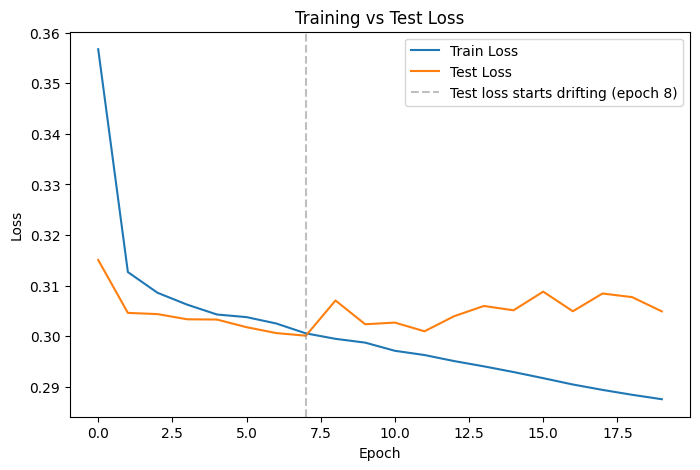

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.axvline(x=7, color='gray', linestyle='--', alpha=0.5, label='Test loss starts drifting (epoch 8)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Test Loss')
plt.legend()
plt.show()

Evaluates the trained model on the held-out test set, converting its raw output into pass/fail probabilities and predictions. A handful of individual predictions are also inspected directly, since aggregate accuracy alone doesn't show how or why the model gets specific cases wrong.

In [11]:
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    probs = torch.sigmoid(logits)              # convert raw logits to probabilities (0-1)
    predictions = (probs >= 0.5).float()

accuracy = (predictions == y_test_tensor).float().mean().item()
print(f"Test Accuracy: {accuracy:.3f}")

# Look at 10 individual predictions
print("\nSample predictions vs actual:")
for i in range(10):
    actual = "  >50K" if y_test_tensor[i].item() == 1 else "<=50K"
    predicted = ">50K" if predictions[i].item() == 1 else "<=50K"
    confidence = probs[i].item()
    match = "✓" if predictions[i].item() == y_test_tensor[i].item() else "✗"
    print(f"{match}  Actual: {actual}   Predicted: {predicted}   Confidence: {confidence:.2f}")

Test Accuracy: 0.863

Sample predictions vs actual:
✓  Actual: <=50K   Predicted: <=50K   Confidence: 0.17
✓  Actual: <=50K   Predicted: <=50K   Confidence: 0.00
✓  Actual:   >50K   Predicted: >50K   Confidence: 0.96
✗  Actual:   >50K   Predicted: <=50K   Confidence: 0.48
✓  Actual: <=50K   Predicted: <=50K   Confidence: 0.02
✓  Actual: <=50K   Predicted: <=50K   Confidence: 0.01
✓  Actual: <=50K   Predicted: <=50K   Confidence: 0.02
✗  Actual: <=50K   Predicted: >50K   Confidence: 0.78
✓  Actual: <=50K   Predicted: <=50K   Confidence: 0.32
✓  Actual: <=50K   Predicted: <=50K   Confidence: 0.04


**Summary**

This model reaches 86.3% test accuracy, a real ~10-point improvement over the 76% majority-class baseline, showing it learned genuine patterns linking education, occupation, and hours worked to income. The loss curve shows mild overfitting after epoch 8, and error inspection revealed a mix of low-confidence borderline mistakes and a few confident wrong predictions both reasonable behavior for a first, untuned model. Limitation: no hyperparameter tuning yet (that's Task 2.3), and the network architecture was chosen without systematic comparison.